In [13]:
!pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

In [14]:
df=pd.read_csv("/content/creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/tmp/ipykernel_3726/4141816675.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


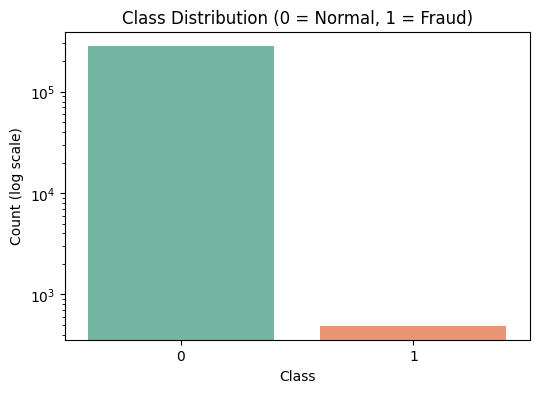

In [15]:
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("Class counts:\n", fraud_count)
print("\nClass percentage:\n", fraud_pct)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.yscale('log')
plt.ylabel("Count (log scale)")
plt.show()

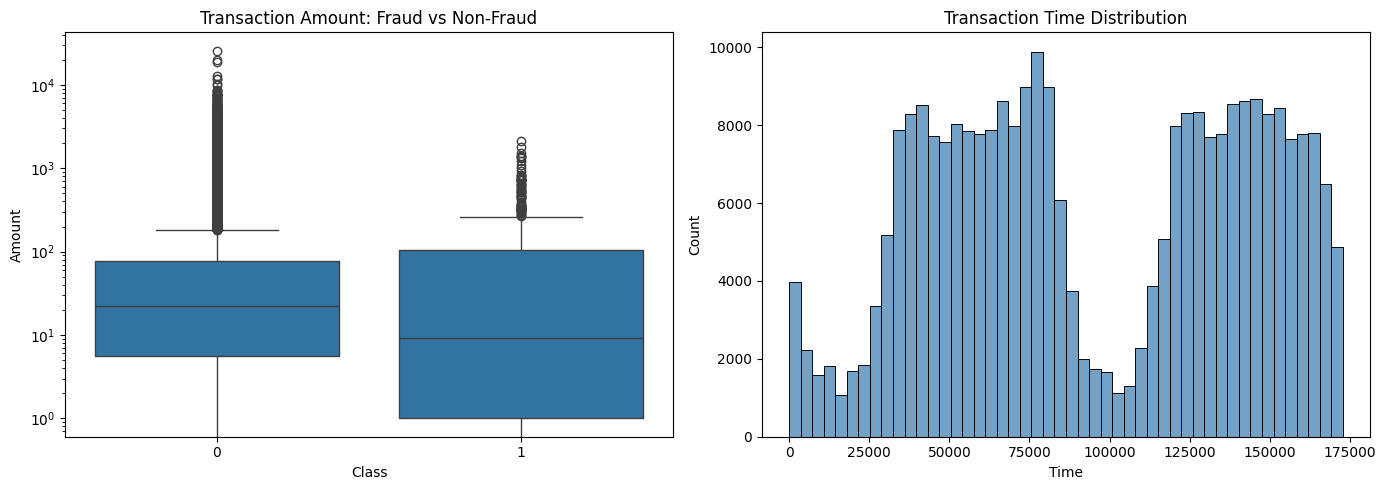

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title("Transaction Amount: Fraud vs Non-Fraud")
axes[0].set_yscale('log')

sns.histplot(df['Time'], bins=48, kde=False, ax=axes[1], color='steelblue')
axes[1].set_title("Transaction Time Distribution")

plt.tight_layout()
plt.show()

"Fraudulent transactions make up only ~0.17% of the dataset. This extreme imbalance means a model predicting 'not fraud' every time would still score >99% accuracy while catching zero actual fraud cases — which is why accuracy alone is a misleading metric here."

In [17]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE - Train class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Train class distribution:")
print(y_train_res.value_counts())

Before SMOTE - Train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE - Train class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {"model": model, "y_pred": y_pred, "y_proba": y_proba,
                      "precision": precision, "recall": recall, "f1": f1, "auc": auc}

    print(f"=== {name} ===")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
    print("-"*60)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Precision: 0.1191 | Recall: 0.8980 | F1: 0.2103 | AUC-ROC: 0.9760
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

------------------------------------------------------------
=== Decision Tree ===
Precision: 0.0886 | Recall: 0.8776 | F1: 0.1609 | AUC-ROC: 0.9402
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.09      0.88      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.93      0.58     56962
weighted avg       1.00      0.98      0.99     56962

------------------------------------------------------------


Logistic Regression achieved a recall of 89.8%, while Decision Tree achieved 87.8% — both models caught the vast majority of fraud cases, with Logistic Regression catching slightly more. In fraud detection, recall matters most because a missed fraud case (false negative) means direct financial loss to the customer or bank.
Logistic Regression also had noticeably better precision (11.9% vs 8.9%) and a higher AUC-ROC score (0.976 vs 0.940), meaning it produced fewer false alarms per fraud caught while maintaining similarly strong recall. Given that Logistic Regression offers both higher recall and better overall discriminative ability (AUC-ROC), it would be the better choice for deployment, despite both models having low absolute precision — a known trade-off in extremely imbalanced datasets like this one, where SMOTE-based oversampling naturally leads to more false positives among the "Fraud" predictions.

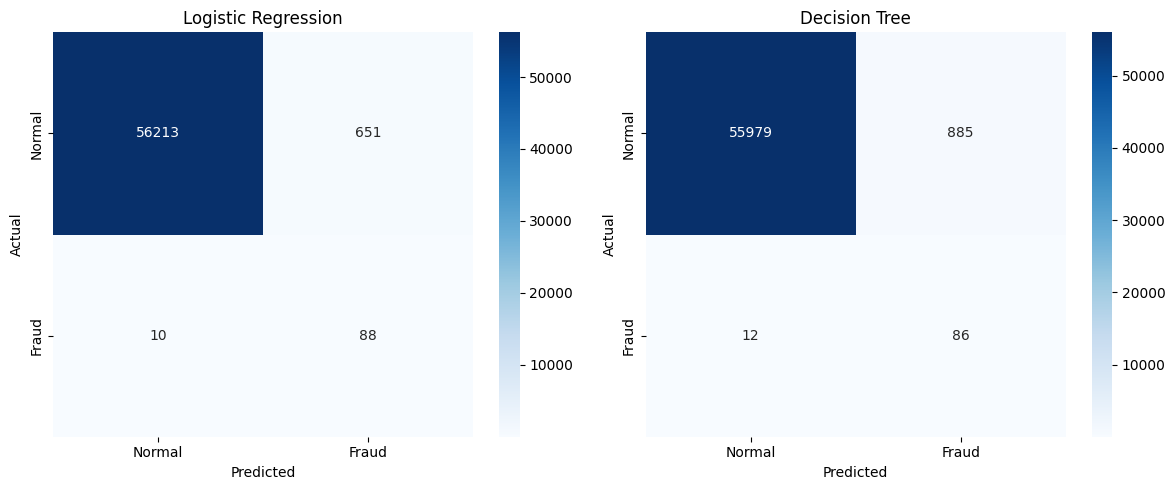

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

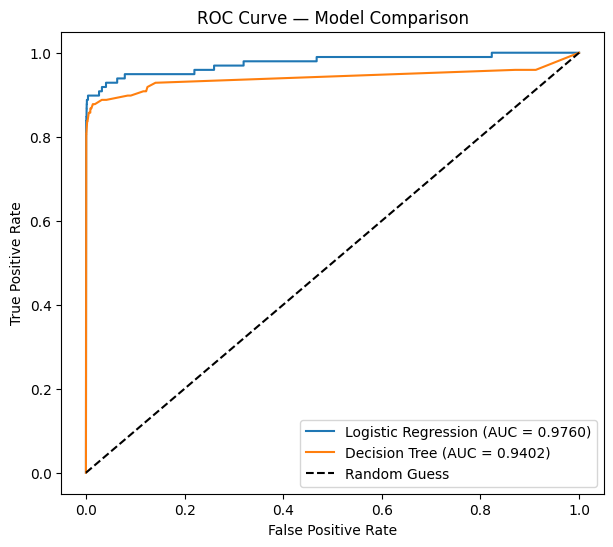

In [19]:
plt.figure(figsize=(7,6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend()
plt.show()

/tmp/ipykernel_3726/2427898157.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


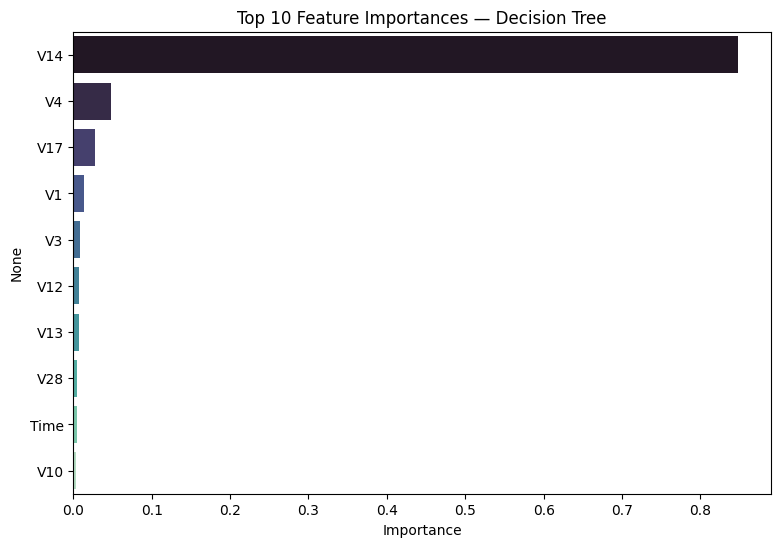

,0
V14,0.847286
V4,0.047893
V17,0.028222
V1,0.013066
V3,0.007976
V12,0.007748
V13,0.006935
V28,0.004835
Time,0.004497
V10,0.003819


In [20]:
dt_model = results["Decision Tree"]["model"]
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.show()

importances

"At ~278 transactions/second, Logistic Regression's simple linear computation makes it extremely fast for real-time inference. The model would need periodic retraining (daily/weekly) as fraud patterns evolve, since this is a batch-trained model, not online learning. Feature computation at this scale would need a streaming pipeline (e.g., Kafka + Spark) rather than synchronous per-request calculation. Importantly, SMOTE is only applied during training on historical data — it adds zero latency at inference time. Finally, the classification threshold could be lowered from the default 0.5 to catch more fraud cases, accepting more false positives, since recall is prioritized here."